In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/Supermart Grocery Sales - Retail Analytics Dataset.csv')

df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [3]:
df.tail()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
9989,OD9990,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10,Tamil Nadu
9990,OD9991,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70,Tamil Nadu
9991,OD9992,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44,Tamil Nadu
9992,OD9993,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24,Tamil Nadu
9993,OD9994,Ganesh,Food Grains,Atta & Flour,Tirunelveli,4/17/2018,West,1034,0.28,165.44,Tamil Nadu


In [4]:
df.shape

(9994, 11)

In [5]:
df.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

In [6]:
df.dtypes

,0
Order ID,object
Customer Name,object
Category,object
Sub Category,object
City,object
Order Date,object
Region,object
Sales,int64
Discount,float64
Profit,float64


In [7]:
df.isnull().sum()

,0
Order ID,0
Customer Name,0
Category,0
Sub Category,0
City,0
Order Date,0
Region,0
Sales,0
Discount,0
Profit,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique()[:20])


 Order ID
['OD1' 'OD2' 'OD3' 'OD4' 'OD5' 'OD6' 'OD7' 'OD8' 'OD9' 'OD10' 'OD11'
 'OD12' 'OD13' 'OD14' 'OD15' 'OD16' 'OD17' 'OD18' 'OD19' 'OD20']

 Customer Name
['Harish' 'Sudha' 'Hussain' 'Jackson' 'Ridhesh' 'Adavan' 'Jonas' 'Hafiz'
 'Krithika' 'Ganesh' 'Yadav' 'Sharon' 'Peer' 'Sundar' 'Ramesh' 'Alan'
 'Arutra' 'Haseena' 'Verma' 'Muneer']

 Category
['Oil & Masala' 'Beverages' 'Food Grains' 'Fruits & Veggies' 'Bakery'
 'Snacks' 'Eggs, Meat & Fish']

 Sub Category
['Masalas' 'Health Drinks' 'Atta & Flour' 'Fresh Vegetables'
 'Organic Staples' 'Fresh Fruits' 'Biscuits' 'Cakes' 'Chocolates' 'Eggs'
 'Cookies' 'Chicken' 'Edible Oil & Ghee' 'Mutton' 'Soft Drinks'
 'Dals & Pulses' 'Organic Vegetables' 'Noodles' 'Organic Fruits' 'Fish']

 City
['Vellore' 'Krishnagiri' 'Perambalur' 'Dharmapuri' 'Ooty' 'Trichy'
 'Ramanadhapuram' 'Tirunelveli' 'Chennai' 'Karur' 'Namakkal' 'Dindigul'
 'Kanyakumari' 'Bodi' 'Tenkasi' 'Viluppuram' 'Madurai' 'Salem' 'Cumbum'
 'Nagercoil']

 Order Date
['11-08-2017' '

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [13]:
df['Order Date'].dtype


dtype('<M8[ns]')

In [14]:
df.describe()


,Order Date,Sales,Discount,Profit
count,4042,9994.000000,9994.000000,9994.000000
mean,2017-04-28 03:16:17.931716864,1496.596158,0.226817,374.937082
min,2015-01-03 00:00:00,500.000000,0.100000,25.250000
25%,2016-05-09 06:00:00,1000.000000,0.160000,180.022500
50%,2017-07-01 00:00:00,1498.000000,0.230000,320.780000
75%,2018-06-01 00:00:00,1994.750000,0.290000,525.627500
max,2018-12-11 00:00:00,2500.000000,0.350000,1120.950000
std,NaN,577.559036,0.074636,239.932881


In [16]:
variables = ['Sales', 'Discount', 'Profit']

for col in variables:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Range:", df[col].max() - df[col].min())
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())


 Sales
Mean: 1496.5961576946167
Median: 1498.0
Mode: 1259
Minimum: 500
Maximum: 2500
Range: 2000
Variance: 333574.4403174681
Standard Deviation: 577.5590362183489

 Discount
Mean: 0.22681709025415253
Median: 0.23
Mode: 0.25
Minimum: 0.1
Maximum: 0.35
Range: 0.24999999999999997
Variance: 0.005570524531270436
Standard Deviation: 0.07463594664282376

 Profit
Mean: 374.9370822493496
Median: 320.78
Mode: 198.0
Minimum: 25.25
Maximum: 1120.95
Range: 1095.7
Variance: 57567.78754047013
Standard Deviation: 239.93288132406974


In [18]:
corr = df[['Sales', 'Discount', 'Profit']].corr()

print(corr)

             Sales  Discount    Profit
Sales     1.000000 -0.005512  0.605349
Discount -0.005512  1.000000  0.000017
Profit    0.605349  0.000017  1.000000


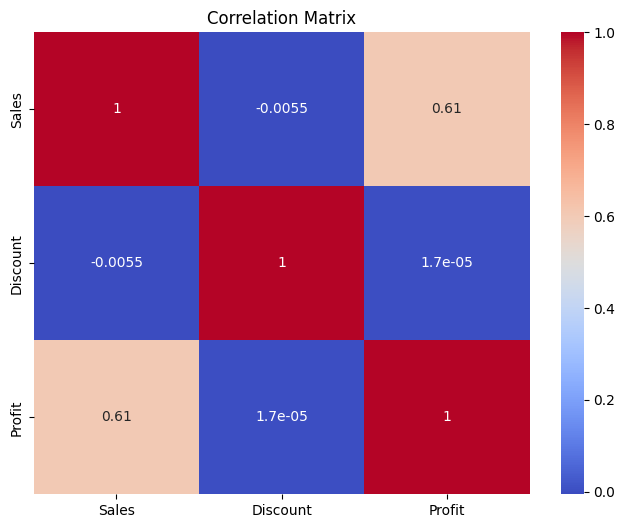

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [21]:
X = df[['Sales']]
y = df['Profit']

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", model.score(X, y))

Coefficient: 0.2514773636527515
Intercept: -1.4229739405301416
R²: 0.36644687695375866


In [22]:
prediction = model.predict([[10]])
print("Predicted Sales:", prediction[0])

Predicted Sales: 1.091799695997373


In [23]:
average_sales = df['Sales'].mean()

probability = (df['Sales'] > average_sales).mean()

print("Probability:", probability)

Probability: 0.5008004802881729
